In [1]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ Memory growth GPU diaktifkan")
    except RuntimeError as e:
        print("❌ Error saat set memory growth:", e)

print("GPU Available:", tf.config.list_physical_devices('GPU'))

2025-12-28 11:13:00.854830: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766920381.037742      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766920381.082495      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


✅ Memory growth GPU diaktifkan
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
!pip install imgaug opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 31.1 MB/s eta 0:00:00


In [3]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 3.0 MB/s eta 0:00:00


In [4]:
import os
import random
import cv2
import dlib
import shutil
import zipfile
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from deepface import DeepFace
from tensorflow.keras import layers, models, optimizers, losses, metrics
from imgaug import augmenters as iaa

25-12-28 11:13:27 - Directory /root/.deepface has been created
25-12-28 11:13:27 - Directory /root/.deepface/weights has been created


In [5]:
# --- Konfigurasi ---
input_dir = "/kaggle/input/meei-no-split"  # dataset asli (langsung berisi folder kelas)
output_dir = "/kaggle/working/faces_dataset_close"  # hasil crop & resize
target_size = (224, 224)  # ukuran output
margin = 40  # margin di sekitar wajah

# Load face detector
detector = dlib.get_frontal_face_detector()

# Bersihkan output folder kalau sudah ada
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir, exist_ok=True)

# Loop langsung ke folder kelas (Complete, Mild, Moderate, dll)
for class_name in os.listdir(input_dir):
    class_path = os.path.join(input_dir, class_name)
    if not os.path.isdir(class_path):
        continue  # skip jika bukan folder

    out_class_path = os.path.join(output_dir, class_name)
    os.makedirs(out_class_path, exist_ok=True)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)

        if len(faces) == 0:
            # Jika tidak ada wajah, skip
            continue

        for i, face in enumerate(faces):
            # Ambil bounding box wajah
            x, y, w, h = face.left(), face.top(), face.width(), face.height()
            x_new = max(0, x - margin)
            y_new = max(0, y - margin)
            w_new = w + 2 * margin
            h_new = h + 2 * margin

            # Crop wajah
            face_roi = img[y_new:y_new+h_new, x_new:x_new+w_new]

            # Resize ke target_size
            face_resized = cv2.resize(face_roi, target_size)

            # Simpan dengan nama sama
            save_path = os.path.join(out_class_path, img_name)
            cv2.imwrite(save_path, face_resized)

# --- Kompres jadi ZIP ---
zip_path = "/kaggle/working/faces_dataset_close.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, output_dir)
            zipf.write(file_path, arcname)

print(f"Dataset wajah selesai diproses.\nFolder output: {output_dir}\nZIP file: {zip_path}")

Dataset wajah selesai diproses.
Folder output: /kaggle/working/faces_dataset_close
ZIP file: /kaggle/working/faces_dataset_close.zip


In [6]:
# --- Konfigurasi Parameter ---
base_root = '/kaggle/working/faces_dataset_close'  # Folder sumber (langsung berisi folder kelas)
output_root = '/kaggle/working/augmented_dataset'         # Folder tujuan utama

# Target jumlah gambar per kelas setelah augmentasi
target_count = 800

img_size = (224, 224)

# --- Definisi Augmentasi ---
augmenter = iaa.Sequential([
    iaa.Fliplr(0.5),               # Horizontal Flip
    iaa.Affine(rotate=(-20, 20)),  # Rotasi
    iaa.Affine(shear=(-20, 20)),   # Shear
    iaa.Affine(scale=(0.8, 1.2))   # Zoom
])

# --- Fungsi Augmentasi Per Kelas ---
def augment_to_target(source_dir, dest_dir, target_count):
    """
    Menyalin gambar asli dan menambahkannya dengan augmentasi
    hingga setiap kelas mencapai jumlah target (target_count).
    """
    class_names = [d for d in os.listdir(source_dir) if os.path.isdir(os.path.join(source_dir, d))]
    
    print("Memproses dan mengaugmentasi dataset...")
    
    for class_name in tqdm(class_names, desc="Kelas"):
        class_input_dir = os.path.join(source_dir, class_name)
        class_output_dir = os.path.join(dest_dir, class_name)
        os.makedirs(class_output_dir, exist_ok=True)

        image_files = [f for f in os.listdir(class_input_dir) if f.lower().endswith(('.jpg', '.png', '.bmp'))]
        
        if not image_files:
            continue
            
        original_images = []

        # Langkah 1: Baca dan simpan semua gambar asli
        for file in image_files:
            img_path = os.path.join(class_input_dir, file)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            original_images.append(img)
            # Simpan gambar asli
            cv2.imwrite(os.path.join(class_output_dir, file), img)

        # Langkah 2: Tambah dengan augmentasi sampai jumlah target terpenuhi
        current_count = len(original_images)
        image_index = 0
        while current_count < target_count:
            img_to_augment = original_images[image_index % len(original_images)]
            
            augmented_img = augmenter(image=img_to_augment)
            
            filename = os.path.join(class_output_dir, f'aug_{current_count + 1:04d}.jpg')
            cv2.imwrite(filename, augmented_img)
            
            current_count += 1
            image_index += 1

# --- Jalankan Proses Augmentasi ---
augment_to_target(base_root, output_root, target_count)

print("\n Augmentasi selesai, setiap kelas memiliki", target_count, "gambar.")

Memproses dan mengaugmentasi dataset...


Kelas: 100%|██████████| 6/6 [00:14<00:00,  2.38s/it]


 Augmentasi selesai, setiap kelas memiliki 800 gambar.


In [7]:
class_names = ['Complete', 'Mild', 'Moderate', 'Near Normal', 'Normal', 'Severe']
print("📦 Membuat dataset pipeline...")

# Gunakan dataset hasil augmentasi
full_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    output_root,
    labels='inferred',
    label_mode='int',
    class_names=class_names,
    image_size=img_size,
    batch_size=None,  # Per gambar
    shuffle=True
)

# Normalisasi
normalization_layer = tf.keras.layers.Rescaling(1./255)
def preprocess(image, label):
    image = normalization_layer(image)
    return image, label

full_dataset = full_dataset.map(preprocess)

# Hitung total
total_size = sum(1 for _ in full_dataset)
print("Total images:", total_size)

# Ubah ke list lalu split
full_dataset_list = list(full_dataset)
random.shuffle(full_dataset_list)

train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

images = [x[0] for x in full_dataset_list]
labels = [x[1] for x in full_dataset_list]

train_images = images[:train_size]
train_labels = labels[:train_size]

val_images = images[train_size:train_size+val_size]
val_labels = labels[train_size:train_size+val_size]

test_images = images[train_size+val_size:]
test_labels = labels[train_size+val_size:]

train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_images, test_labels))

batch_size = 32
train_dataset = train_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f"✅ Train size: {train_size}, Validation size: {val_size}, Test size: {test_size}")

📦 Membuat dataset pipeline...
Found 4800 files belonging to 6 classes.


I0000 00:00:1766920570.827325      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Total images: 4800
✅ Train size: 3360, Validation size: 720, Test size: 720


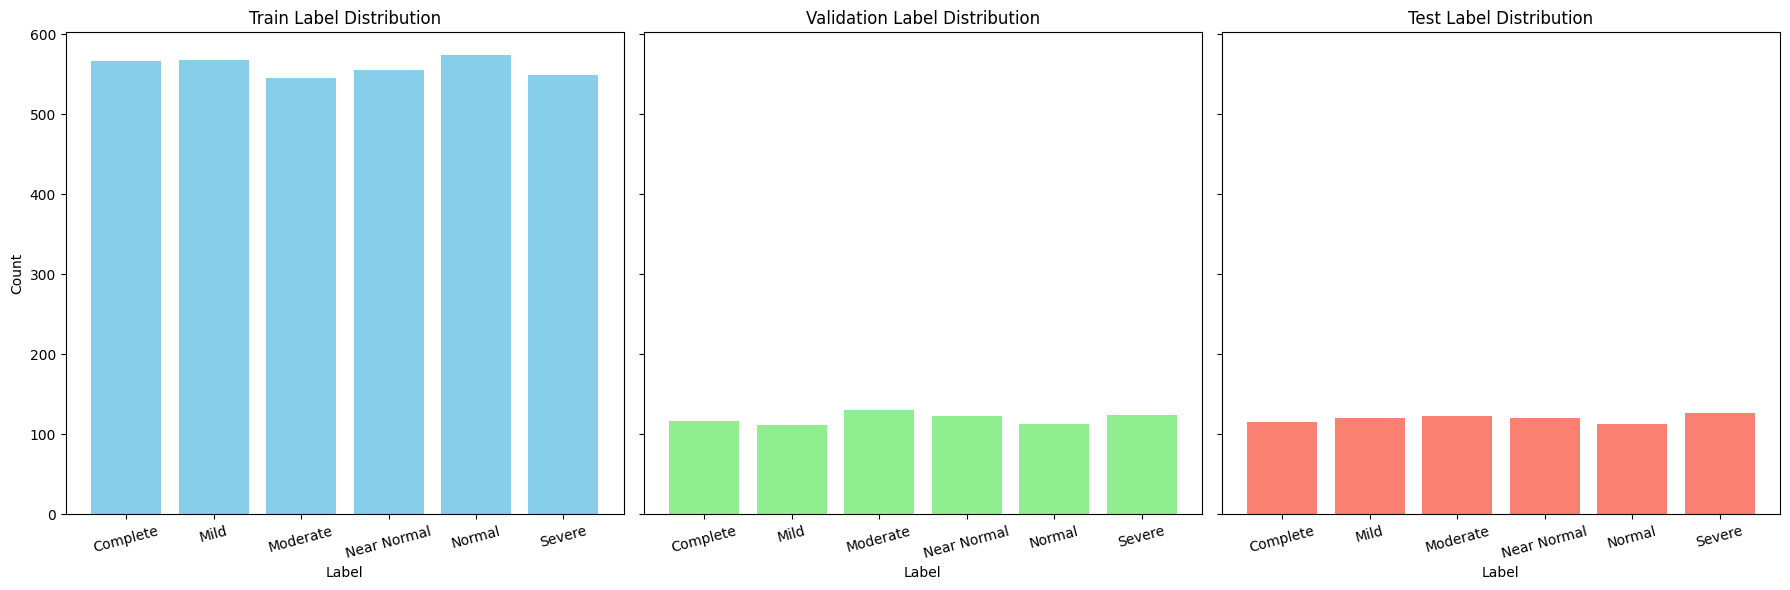

In [8]:
# Fungsi untuk mengumpulkan semua label dari tf.data.Dataset ke list
def collect_labels(dataset):
    labels = []
    for _, batch_labels in dataset:
        labels.extend(batch_labels.numpy().tolist())
    return labels

# Kumpulkan semua label dari dataset train, val, test
all_train_labels = collect_labels(train_dataset)
all_val_labels = collect_labels(val_dataset)
all_test_labels = collect_labels(test_dataset)

# Hitung jumlah masing-masing label
train_counts = Counter(all_train_labels)
val_counts = Counter(all_val_labels)
test_counts = Counter(all_test_labels)

# Daftar semua label unik (urutkan supaya konsisten)
all_labels = sorted(set(train_counts.keys()) | set(val_counts.keys()) | set(test_counts.keys()))

# Nama kelas sesuai label 0–5
class_names = ['Complete', 'Mild', 'Moderate', 'Near Normal', 'Normal', 'Severe']

# Filter hanya label yang valid (agar tidak melebihi panjang class_names)
valid_labels = [l for l in all_labels if l < len(class_names)]

# Buat barplot
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Train
axes[0].bar(valid_labels, [train_counts.get(l, 0) for l in valid_labels], color='skyblue')
axes[0].set_title("Train Label Distribution")
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Count")
axes[0].set_xticks(valid_labels)
axes[0].set_xticklabels([class_names[l] for l in valid_labels], rotation=15)

# Validation
axes[1].bar(valid_labels, [val_counts.get(l, 0) for l in valid_labels], color='lightgreen')
axes[1].set_title("Validation Label Distribution")
axes[1].set_xlabel("Label")
axes[1].set_xticks(valid_labels)
axes[1].set_xticklabels([class_names[l] for l in valid_labels], rotation=15)

# Test
axes[2].bar(valid_labels, [test_counts.get(l, 0) for l in valid_labels], color='salmon')
axes[2].set_title("Test Label Distribution")
axes[2].set_xlabel("Label")
axes[2].set_xticks(valid_labels)
axes[2].set_xticklabels([class_names[l] for l in valid_labels], rotation=15)

plt.tight_layout()
plt.show()

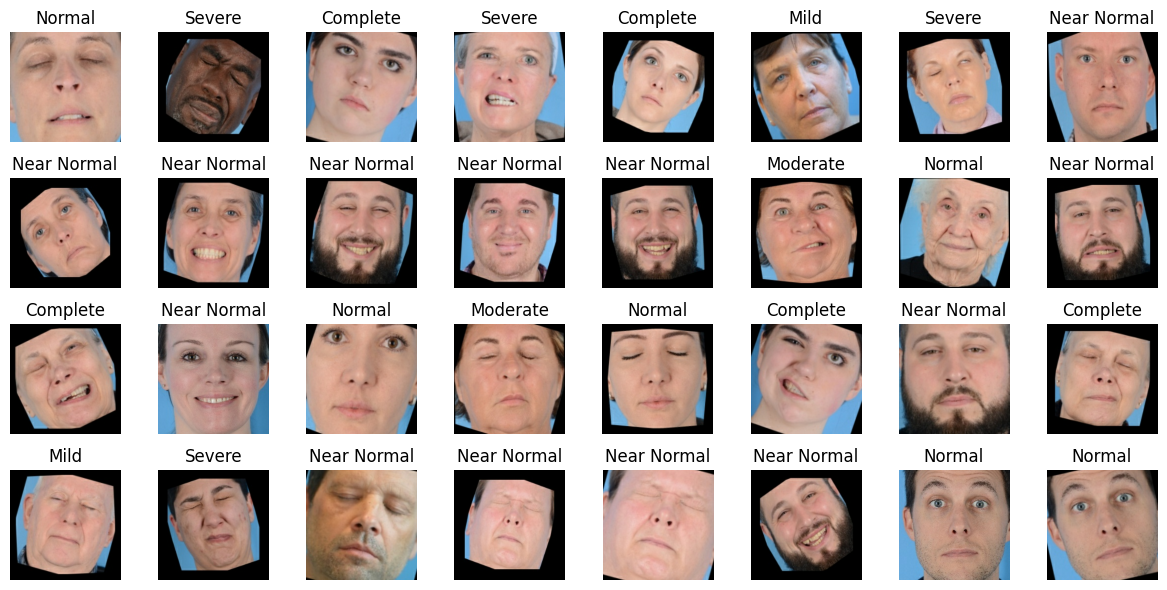

In [9]:
# Fungsi untuk menampilkan batch gambar dalam grid
def imshow(images, labels, class_names):
    # images shape: (batch_size, height, width, channels)
    images = images.numpy()
    
    # Buat grid gambar (misal 4x8 gambar)
    grid_size = (4, 8)  # Sesuaikan dengan batch size jika perlu
    fig, axes = plt.subplots(*grid_size, figsize=(12,6))
    
    idx = 0
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):
            if idx >= len(images):
                break
            ax = axes[i, j]
            img = images[idx]
            # Jika grayscale, hapus channel terakhir jika 1
            if img.shape[-1] == 1:
                img = img.squeeze(-1)
                ax.imshow(img, cmap='gray')
            else:
                ax.imshow(img)
            ax.axis('off')
            ax.set_title(class_names[labels[idx]])
            idx += 1
    
    plt.tight_layout()
    plt.show()

# Ambil satu batch data dari train_dataset (tf.data.Dataset)
for images, labels in train_dataset.take(1):
    imshow(images, labels.numpy(), class_names)

25-12-28 11:16:29 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to /root/.deepface/weights/vgg_face_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5
To: /root/.deepface/weights/vgg_face_weights.h5
100%|██████████| 580M/580M [00:07<00:00, 77.0MB/s]


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_38 (Functional)      │ (None, 4096)           │   134,260,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     4,195,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         6,150 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,462,022 (528.19 MB)

...

Epoch 1/100


I0000 00:00:1766920601.198406      89 service.cc:148] XLA service 0x7cd258002370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766920601.219426      89 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1766920601.652975      89 cuda_dnn.cc:529] Loaded cuDNN version 90300


  2/105 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - loss: 1.7933 - sparse_categorical_accuracy: 0.1797  

I0000 00:00:1766920610.922330      89 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.7481 - sparse_categorical_accuracy: 0.5255
Epoch 1: val_loss improved from inf to 1.56277, saving model to ./checkpoints/best_model.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 174ms/step - loss: 1.7475 - sparse_categorical_accuracy: 0.5272 - val_loss: 1.5628 - val_sparse_categorical_accuracy: 0.8569
Epoch 2/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.4568 - sparse_categorical_accuracy: 0.8596
Epoch 2: val_loss improved from 1.56277 to 1.21067, saving model to ./checkpoints/best_model.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 1.4559 - sparse_categorical_accuracy: 0.8596 - val_loss: 1.2107 - val_sparse_categorical_accuracy: 0.8875
Epoch 3/100
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 1.0939 - sparse_categorical_accuracy: 0.8893
Epoch 3: val_loss improved from 1.21067 to 0.89161, saving model to ./checkpoints/best_model.h5
105/105 ━━━━━━━━━━━━━━━━━━━━ 13s 121ms/step - loss: 1.0931 - sparse_categorical_accuracy: 0

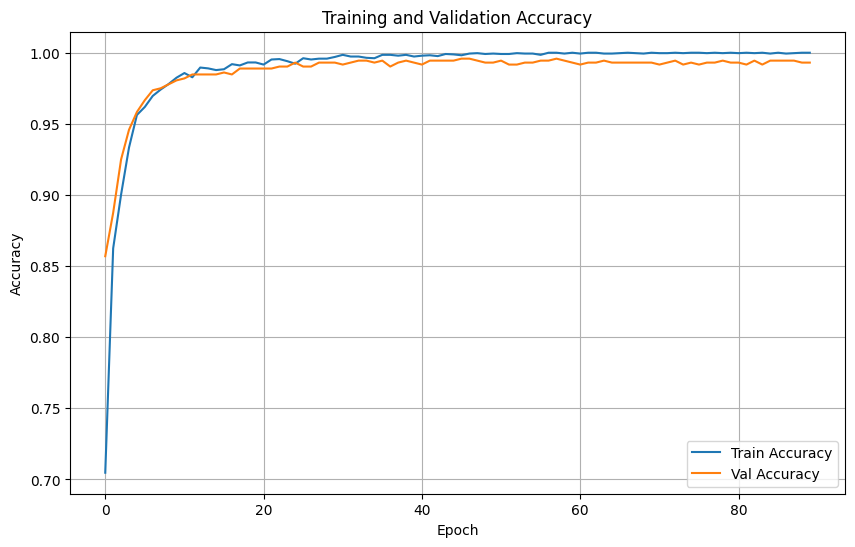

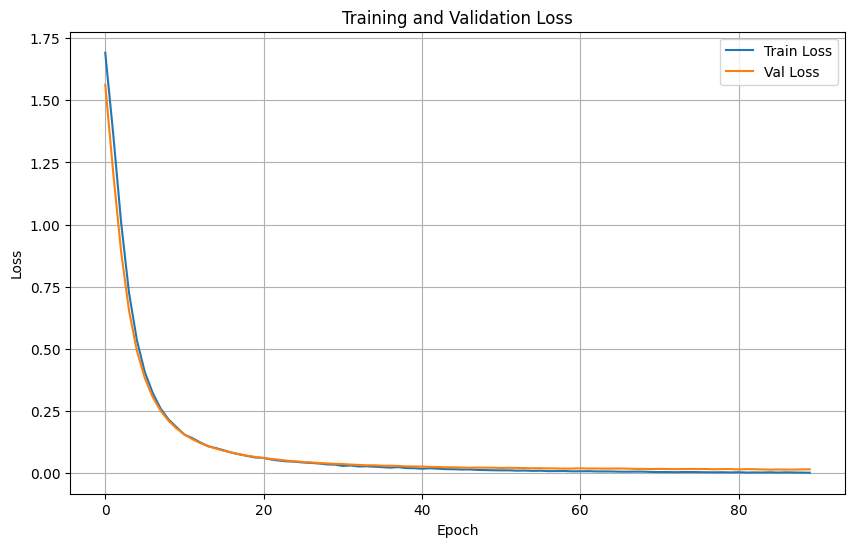

In [10]:
class_labels = ['Complete', 'Mild', 'Moderate', 'Near Normal', 'Normal', 'Severe']
# === Setup kelas dan device ===
num_classes = 6  # multi classification

# === Load pretrained FaceNet (128-dim) dari DeepFace ===
# Ambil wrapper DeepFace
base_obj = DeepFace.build_model("VGG-Face")

# Ambil model keras aslinya
base_model = base_obj.model  
base_model.trainable = False  # freeze backbone

# === Bangun classifier baru ===
inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)  # embedding 128-dim

# opsional: bisa langsung ke dense, tanpa flatten (karena sudah 1D vector)
x = layers.Dense(1024, activation='relu')(x)  
x = layers.Dropout(0.5)(x)  # biar lebih robust

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# === Compile model ===
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss=losses.SparseCategoricalCrossentropy(),
    metrics=[metrics.SparseCategoricalAccuracy()]
)

model.summary()

# === Callback simpan model dan log csv ===
checkpoint_dir = './checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(checkpoint_dir, 'best_model.h5'),
        save_best_only=True,        # hanya simpan model terbaik
        monitor='val_loss',         # monitor validation loss
        mode='min',                 # val_loss makin kecil makin baik
        save_weights_only=False,    # simpan full model (arsitektur + bobot)
        verbose=1
    ),
    # 2. Hentikan training jika tidak ada kemajuan (TAMBAHAN)
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        mode='min',
        patience=5,          # Tunggu 5 epoch, kalau gak turun juga, stop.
        verbose=1,
        restore_best_weights=True # Otomatis load bobot terbaik di akhir
    ),
    
    tf.keras.callbacks.CSVLogger('training_log.csv')
]

# === Training dengan model.fit ===
num_epochs = 100
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=num_epochs,
    callbacks=callbacks
)

print("\nMemuat kembali model terbaik sebelum evaluasi...")
# Load kembali file model terbaik ke dalam variabel 'model'
best_model_path = os.path.join(checkpoint_dir, 'best_model.h5') # Path file
model = tf.keras.models.load_model(best_model_path)             # <--- TAMBAHAN PENTING

# === Evaluasi menggunakan DATA VALIDASI ===
y_true_val, y_pred_val = [], []

for images, labels in val_dataset:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)
    y_pred_val.extend(pred_labels)
    y_true_val.extend(labels.numpy())

val_precision = precision_score(y_true_val, y_pred_val, average='macro')
val_recall = recall_score(y_true_val, y_pred_val, average='macro')
val_f1 = f1_score(y_true_val, y_pred_val, average='macro')
val_accuracy = accuracy_score(y_true_val, y_pred_val)

print(f"[VALIDATION] Accuracy: {val_accuracy:.4f}")
print(f"[VALIDATION] Precision (macro): {val_precision:.4f}")
print(f"[VALIDATION] Recall (macro): {val_recall:.4f}")
print(f"[VALIDATION] F1 Score (macro): {val_f1:.4f}")

# Tambahan (opsional): klasifikasi per kelas
print("\nClassification Report:")
print(classification_report(y_true_val, y_pred_val, target_names=class_labels, digits=3))

# Tambahan: Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_true_val, y_pred_val))

# Baca file log
log_df = pd.read_csv('training_log.csv')

# Plot accuracy
plt.figure(figsize=(10, 6))
plt.plot(log_df['epoch'], log_df['sparse_categorical_accuracy'], label='Train Accuracy')
plt.plot(log_df['epoch'], log_df['val_sparse_categorical_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot loss
plt.figure(figsize=(10, 6))
plt.plot(log_df['epoch'], log_df['loss'], label='Train Loss')
plt.plot(log_df['epoch'], log_df['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

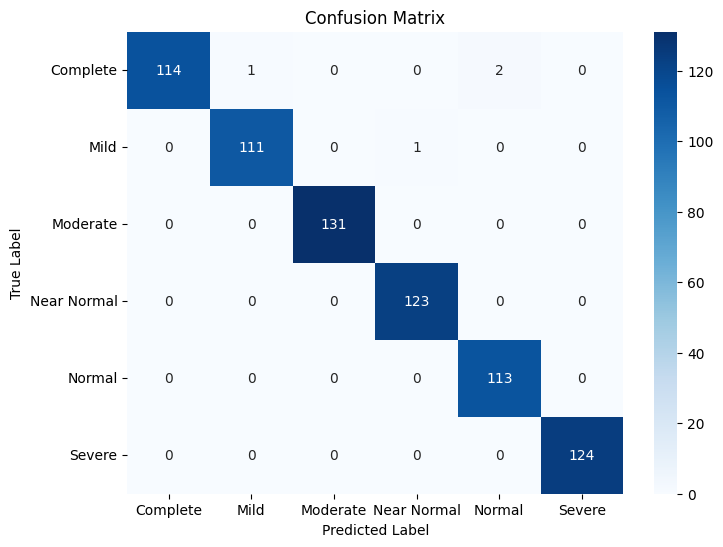

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Hitung confusion matrix
cm = confusion_matrix(y_true_val, y_pred_val)

# Plot confusion matrix dengan heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, 
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [12]:
from datetime import datetime
save_dir = "/kaggle/working/saved_models"
os.makedirs(save_dir, exist_ok=True)

# Nama file model disertai waktu training
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"vggface_model_{timestamp}"

In [13]:
# --- 3️⃣ (Opsional) Simpan versi compact HDF5 untuk keperluan deployment ---
h5_path = os.path.join(save_dir, f"{model_name}.h5")
model.save(h5_path)
print(f"📦 Model lengkap juga disimpan dalam format .h5: {h5_path}")

📦 Model lengkap juga disimpan dalam format .h5: /kaggle/working/saved_models/vggface_model_20251228_113506.h5
